<a href="https://colab.research.google.com/github/TOTVScontext/DataScience/blob/main/context.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
#Leonardo da Silva Pinto | RM: 564929
#Samuel Enzo Domingues Monteiro | RM: 564391
#Guilherme de Araujo Moreira | RM: 561848

# Sprint 3 — Machine Learning Supervisionado para NLP

**Disciplina:** Data Science and Statistical Computing  
**Objetivo:** construir e avaliar modelos supervisionados capazes de classificar transcrições de reuniões em problemas de negócio, comparando dois algoritmos e justificando as métricas utilizadas.

## 1. Definição do problema e estratégia multitarefa

A base tabular contém reuniões transcritas e metadados de negócio. O pipeline segmenta as falas para a etapa de preparação, mas realiza a modelagem no **nível da reunião**. Essa decisão evita que falas da mesma reunião apareçam simultaneamente nos conjuntos de treino e teste e recebam rótulos repetidos de forma artificial.

Serão estudados três alvos:

| Problema de negócio | Variável-alvo | Definição utilizada | Observação metodológica |
|---|---|---|---|
| Risco de churn ou insatisfação | `TARGET_RISCO` | 1 para NPS de 0 a 6; 0 para NPS de 7 a 10 | É um proxy de risco baseado no NPS, não uma observação direta de cancelamento. |
| Oportunidade comercial | `TARGET_OPORTUNIDADE` | 1 quando `TP_RECURSO` indica Vendas/Comercial; 0 nos demais casos | É um proxy de oportunidade, pois a base não apresenta uma anotação humana explícita de oportunidade no texto. |
| Sentimento | `TARGET_SENTIMENTO` | Negativo para NPS de 0 a 4; Neutro para NPS de 5 a 7; Positivo para NPS de 8 a 10 | É um proxy supervisionado de sentimento derivado do NPS; idealmente deveria ser validado por anotadores humanos. |

O produto mencionado será tratado como uma quarta frente de negócio na base JSON. Como não há rótulo supervisionado de produto, essa etapa será uma **extração determinística por regras**, e não será comparada por métricas de classificação.

> A interpretação dos resultados deve distinguir claramente entre o que foi medido no conjunto de teste e o que é apenas uma hipótese operacional para aplicação em dados reais.

In [23]:
# 2. Setup, importações e carga das bases
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import nltk
from IPython.display import display
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

try:
    nltk.download('stopwords', quiet=True)
    stop_words_pt = set(stopwords.words('portuguese'))
except Exception:
    # Fallback para ambientes sem acesso ao repositório do NLTK.
    stop_words_pt = set()

# Termos de negação são importantes em tarefas de sentimento e, por isso,
# não são removidos mesmo quando aparecem na lista de stopwords.
stop_words_pt -= {'não', 'nem', 'nunca', 'jamais', 'sem'}

def localizar_arquivo(nome):
    candidatos = [
        Path.cwd() / nome,
        Path('/content') / nome,
        Path('/home/ubuntu') / nome,
        Path('/home/ubuntu/upload') / nome,
    ]
    for candidato in candidatos:
        if candidato.exists():
            return candidato
    caminhos = '\n'.join(f'- {c}' for c in candidatos)
    raise FileNotFoundError(
        f'Arquivo {nome!r} não encontrado. Coloque-o na mesma pasta do notebook. '
        f'Caminhos verificados:\n{caminhos}'
    )

ARQUIVO_CSV = localizar_arquivo('reunioes_transcricoes_mockado.csv')
ARQUIVO_JSON = localizar_arquivo('ANON_transcricao.json')

df_csv = pd.read_csv(ARQUIVO_CSV)
df_json = pd.read_json(ARQUIVO_JSON, lines=True)

colunas_csv_obrigatorias = {'ID_MEETING', 'ANON_TRANSCRICAO', 'NOTA_NPS', 'TP_RECURSO'}
colunas_json_obrigatorias = {'ID_MEETING', 'ANON_TRANSCRICAO'}

faltantes_csv = colunas_csv_obrigatorias.difference(df_csv.columns)
faltantes_json = colunas_json_obrigatorias.difference(df_json.columns)
if faltantes_csv:
    raise ValueError(f'Colunas ausentes no CSV: {sorted(faltantes_csv)}')
if faltantes_json:
    raise ValueError(f'Colunas ausentes no JSON: {sorted(faltantes_json)}')

df_csv['NOTA_NPS'] = pd.to_numeric(df_csv['NOTA_NPS'], errors='coerce')
df_csv_modelo = df_csv.dropna(subset=['NOTA_NPS']).copy()

print(f'CSV carregado: {df_csv.shape[0]} reuniões; {df_csv_modelo.shape[0]} com NPS válido para modelagem.')
print(f'JSON carregado: {df_json.shape[0]} reuniões para inferência e extração de produtos.')

CSV carregado: 500 reuniões; 500 com NPS válido para modelagem.
JSON carregado: 1174 reuniões para inferência e extração de produtos.


## 2. Segmentação, limpeza e preparação dos alvos

A segmentação abaixo transforma cada transcrição em falas individuais, preservando o identificador da reunião. Em seguida, as falas limpas são concatenadas no nível da reunião para que a divisão entre treino e teste ocorra por reunião, e não por fala.

A construção dos alvos é apresentada antes do treinamento para tornar explícitas as hipóteses de negócio. O rótulo de oportunidade é uma aproximação baseada no campo `TP_RECURSO`; para uma solução de produção, recomenda-se substituir esse proxy por uma anotação humana do conteúdo comercial da conversa.

In [24]:
# 3. Segmentação, criação das variáveis-alvo e limpeza textual
def segmentar_transcricoes(df, coluna_texto, coluna_id, colunas_extras=None):
    colunas_extras = colunas_extras or []
    registros = []

    for _, row in df.iterrows():
        texto = '' if pd.isna(row[coluna_texto]) else str(row[coluna_texto])
        falas = []
        for linha in texto.splitlines():
            linha = linha.strip()
            if not linha:
                continue
            if ':' in linha:
                locutor, fala = linha.split(':', 1)
                fala = fala.strip()
                if fala:
                    falas.append((locutor.strip(), fala))
            else:
                # Mantém linhas sem marcador de locutor em vez de descartá-las.
                falas.append(('DESCONHECIDO', linha))

        if not falas and texto.strip():
            falas = [('DESCONHECIDO', texto.strip())]

        for locutor, fala in falas:
            registro = {
                'ID_MEETING': row[coluna_id],
                'LOCUTOR': locutor,
                'FALA_BRUTA': fala,
            }
            for coluna in colunas_extras:
                registro[coluna] = row[coluna]
            registros.append(registro)

    return pd.DataFrame(registros)


def mapear_oportunidade(valor):
    texto = str(valor).upper()
    return int(bool(re.search(r'\b(VENDAS?|COMERCIAL|SALES)\b', texto)))


def classificar_sentimento_por_nps(nps):
    if nps >= 8:
        return 'Positivo'
    if nps >= 5:
        return 'Neutro'
    return 'Negativo'


def limpar_texto(texto):
    texto = '' if pd.isna(texto) else str(texto).lower()
    # Preserva o conteúdo de marcações anonimizadas, removendo apenas os delimitadores.
    texto = re.sub(r'\[(.*?)\]', r' \1 ', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto, flags=re.UNICODE)
    palavras = [palavra for palavra in texto.split() if palavra not in stop_words_pt]
    return ' '.join(palavras)


df_trechos = segmentar_transcricoes(
    df_csv_modelo,
    coluna_texto='ANON_TRANSCRICAO',
    coluna_id='ID_MEETING',
    colunas_extras=['NOTA_NPS', 'TP_RECURSO'],
)

if df_trechos.empty:
    raise ValueError('Nenhuma fala válida foi encontrada no CSV.')

df_trechos['TARGET_RISCO'] = (df_trechos['NOTA_NPS'] <= 6).astype(int)
df_trechos['TARGET_OPORTUNIDADE'] = df_trechos['TP_RECURSO'].apply(mapear_oportunidade)
df_trechos['TARGET_SENTIMENTO'] = df_trechos['NOTA_NPS'].apply(classificar_sentimento_por_nps)
df_trechos['FALA_LIMPA'] = df_trechos['FALA_BRUTA'].apply(limpar_texto)

df_reuniao = (
    df_trechos.groupby('ID_MEETING', as_index=False)
    .agg({
        'FALA_LIMPA': ' '.join,
        'TARGET_RISCO': 'first',
        'TARGET_OPORTUNIDADE': 'first',
        'TARGET_SENTIMENTO': 'first',
        'NOTA_NPS': 'first',
        'TP_RECURSO': 'first',
    })
)

print(f'Segmentação: {df_trechos.shape[0]} falas válidas.')
print(f'Modelagem: {df_reuniao.shape[0]} reuniões únicas.')
print(f'Reuniões com texto limpo vazio: {(df_reuniao["FALA_LIMPA"].str.len() == 0).sum()}')

Segmentação: 3750 falas válidas.
Modelagem: 500 reuniões únicas.
Reuniões com texto limpo vazio: 0


## 3. Análise das classes e decisão de balanceamento

Antes do treinamento, verificamos a distribuição das classes. A acurácia isolada pode ser enganosa quando uma classe é majoritária; por isso, o relatório também exibirá métricas macro e métricas específicas para a classe de interesse.

Neste trabalho, a Regressão Logística utiliza `class_weight='balanced'`. Para manter a comparação explícita, o Multinomial Naive Bayes recebe pesos de observação inversamente proporcionais à frequência das classes. O baseline de classe majoritária permanece sem balanceamento e serve como referência mínima.

,Alvo,Variável,Classe,Quantidade,Percentual
0,Risco de churn,TARGET_RISCO,1,327,65.4%
1,Risco de churn,TARGET_RISCO,0,173,34.6%
2,Oportunidade comercial,TARGET_OPORTUNIDADE,0,318,63.6%
3,Oportunidade comercial,TARGET_OPORTUNIDADE,1,182,36.4%
4,Sentimento,TARGET_SENTIMENTO,Negativo,234,46.8%
5,Sentimento,TARGET_SENTIMENTO,Neutro,142,28.4%
6,Sentimento,TARGET_SENTIMENTO,Positivo,124,24.8%


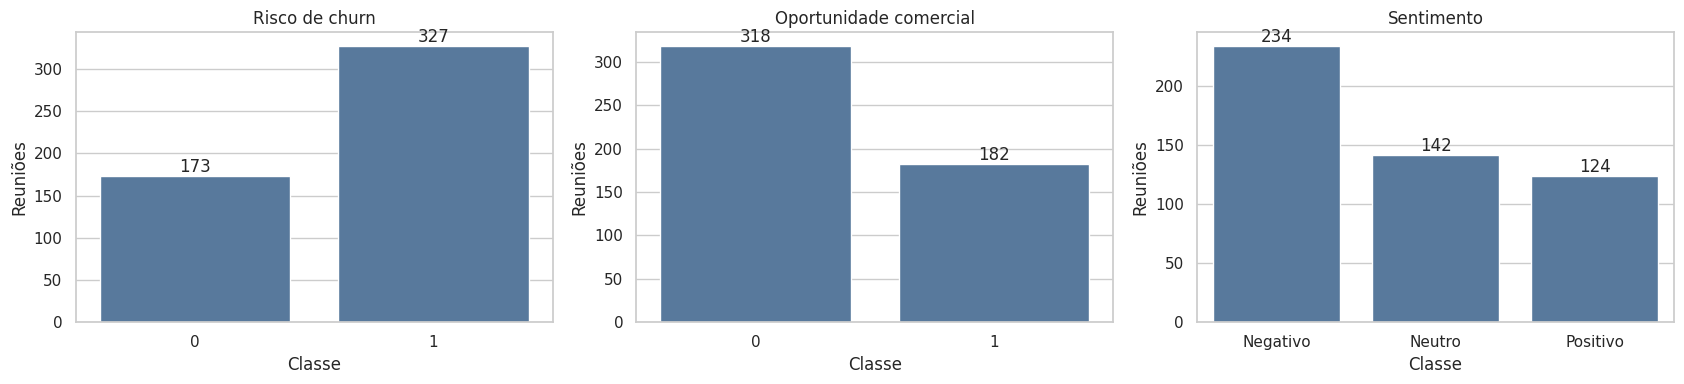

In [25]:
# 4. Distribuição das classes e visualização do balanceamento
alvos = ['TARGET_RISCO', 'TARGET_OPORTUNIDADE', 'TARGET_SENTIMENTO']
nomes_alvos = {
    'TARGET_RISCO': 'Risco de churn',
    'TARGET_OPORTUNIDADE': 'Oportunidade comercial',
    'TARGET_SENTIMENTO': 'Sentimento',
}

linhas_distribuicao = []
for alvo in alvos:
    contagens = df_reuniao[alvo].value_counts(dropna=False)
    for classe, quantidade in contagens.items():
        linhas_distribuicao.append({
            'Alvo': nomes_alvos[alvo],
            'Variável': alvo,
            'Classe': classe,
            'Quantidade': int(quantidade),
            'Percentual': float(quantidade / len(df_reuniao)),
        })

df_distribuicao = pd.DataFrame(linhas_distribuicao)
display(df_distribuicao.style.format({'Percentual': '{:.1%}'}))

fig, axes = plt.subplots(1, len(alvos), figsize=(17, 4))
for ax, alvo in zip(axes, alvos):
    dados = df_reuniao[alvo].value_counts().sort_index().rename_axis('Classe').reset_index(name='Quantidade')
    sns.barplot(data=dados, x='Classe', y='Quantidade', ax=ax, color='#4C78A8')
    ax.set_title(nomes_alvos[alvo])
    ax.set_xlabel('Classe')
    ax.set_ylabel('Reuniões')
    for container in ax.containers:
        ax.bar_label(container, fmt='%d')
plt.tight_layout()
plt.show()

## 4. Vetorização, treinamento e avaliação comparativa

Serão comparados dois algoritmos supervisionados:

1. **Regressão Logística:** modelo linear adequado a matrizes esparsas de TF-IDF, com interpretação por pesos das características e ponderação das classes.
2. **Multinomial Naive Bayes:** baseline probabilístico tradicional para texto, treinado sobre as mesmas características TF-IDF e com pesos de observação para reduzir o efeito do desbalanceamento.

A vetorização foi colocada dentro de um `Pipeline`. Assim, o vocabulário e os valores de IDF são ajustados exclusivamente no conjunto de treino de cada alvo. Essa alteração corrige o vazamento de informação existente na versão anterior, na qual o TF-IDF era ajustado antes da divisão treino/teste.

### Métricas escolhidas

| Problema | Métrica prioritária | Justificativa |
|---|---|---|
| Risco de churn | Recall da classe 1 | Um falso negativo representa deixar de abordar um cliente potencialmente insatisfeito. |
| Oportunidade comercial | F1-score da classe 1 | Equilibra não perder oportunidades e não sobrecarregar Vendas com falsos positivos. |
| Sentimento | F1-score macro | Dá o mesmo peso a Negativo, Neutro e Positivo, mesmo que as classes tenham tamanhos diferentes. |
| Todos os problemas | Accuracy e matriz de confusão | Complementam a leitura, mas não substituem a métrica prioritária. |

O baseline sempre prevê a classe majoritária do conjunto de treino. Um modelo só deve ser considerado útil quando superar esse baseline na métrica prioritária e apresentar comportamento coerente na matriz de confusão.


Alvo: TARGET_RISCO
Distribuição no treino: {1: 229, 0: 121}
Distribuição no teste: {1: 98, 0: 52}

Regressão Logística
              precision    recall  f1-score   support

           0       0.28      0.37      0.32        52
           1       0.60      0.50      0.54        98

    accuracy                           0.45       150
   macro avg       0.44      0.43      0.43       150
weighted avg       0.49      0.45      0.47       150



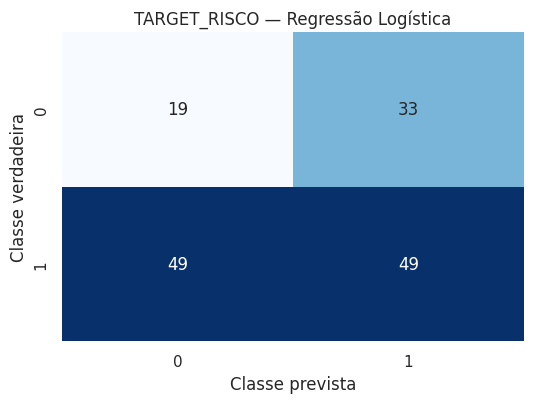


Multinomial Naive Bayes
              precision    recall  f1-score   support

           0       0.28      0.37      0.32        52
           1       0.60      0.50      0.54        98

    accuracy                           0.45       150
   macro avg       0.44      0.43      0.43       150
weighted avg       0.49      0.45      0.47       150



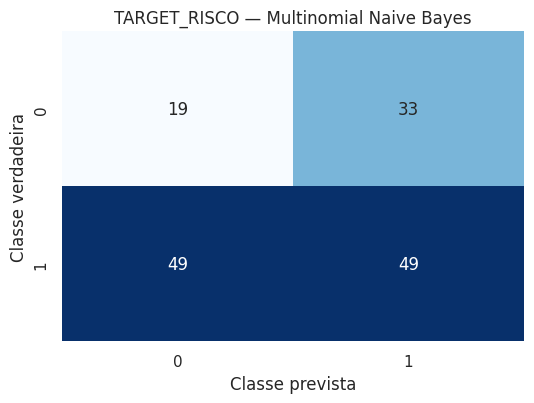


Baseline — sempre prevê np.int64(1)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        52
           1       0.65      1.00      0.79        98

    accuracy                           0.65       150
   macro avg       0.33      0.50      0.40       150
weighted avg       0.43      0.65      0.52       150



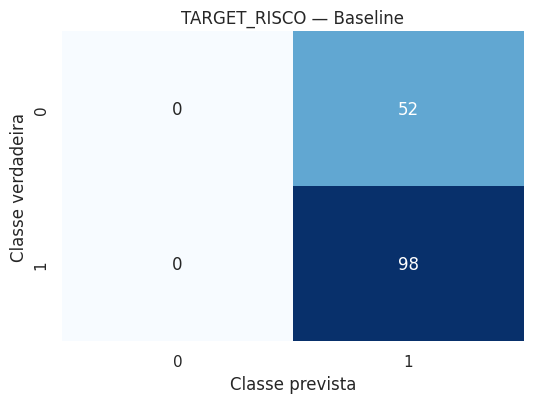


Alvo: TARGET_OPORTUNIDADE
Distribuição no treino: {0: 223, 1: 127}
Distribuição no teste: {0: 95, 1: 55}

Regressão Logística
              precision    recall  f1-score   support

           0       0.67      0.52      0.58        95
           1       0.40      0.56      0.47        55

    accuracy                           0.53       150
   macro avg       0.54      0.54      0.53       150
weighted avg       0.57      0.53      0.54       150



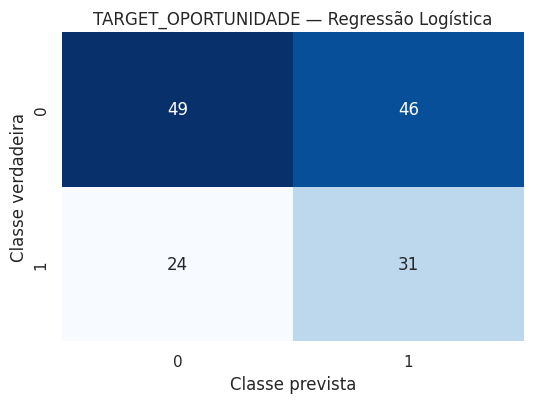


Multinomial Naive Bayes
              precision    recall  f1-score   support

           0       0.67      0.52      0.58        95
           1       0.40      0.56      0.47        55

    accuracy                           0.53       150
   macro avg       0.54      0.54      0.53       150
weighted avg       0.57      0.53      0.54       150



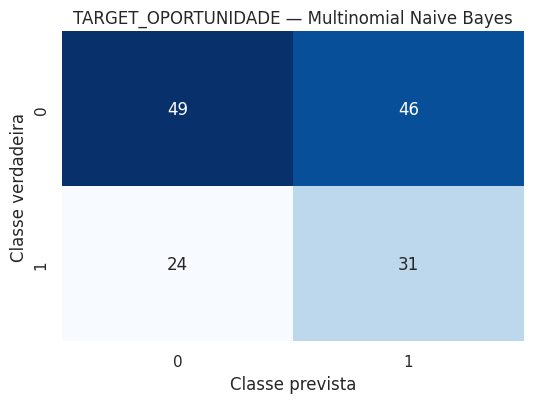


Baseline — sempre prevê np.int64(0)
              precision    recall  f1-score   support

           0       0.63      1.00      0.78        95
           1       0.00      0.00      0.00        55

    accuracy                           0.63       150
   macro avg       0.32      0.50      0.39       150
weighted avg       0.40      0.63      0.49       150



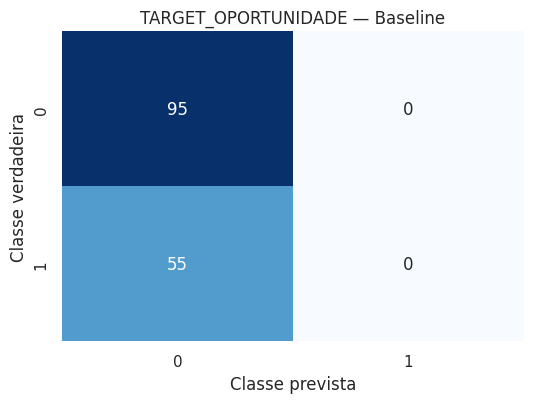


Alvo: TARGET_SENTIMENTO
Distribuição no treino: {'Negativo': 164, 'Neutro': 99, 'Positivo': 87}
Distribuição no teste: {'Negativo': 70, 'Neutro': 43, 'Positivo': 37}

Regressão Logística
              precision    recall  f1-score   support

    Negativo       0.39      0.19      0.25        70
      Neutro       0.20      0.16      0.18        43
    Positivo       0.21      0.46      0.29        37

    accuracy                           0.25       150
   macro avg       0.27      0.27      0.24       150
weighted avg       0.29      0.25      0.24       150



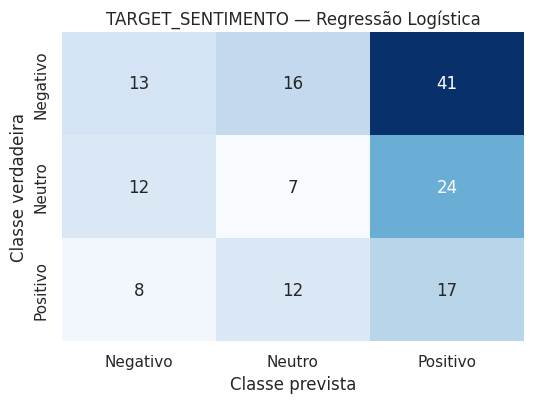


Multinomial Naive Bayes
              precision    recall  f1-score   support

    Negativo       0.39      0.19      0.25        70
      Neutro       0.20      0.16      0.18        43
    Positivo       0.21      0.46      0.29        37

    accuracy                           0.25       150
   macro avg       0.27      0.27      0.24       150
weighted avg       0.29      0.25      0.24       150



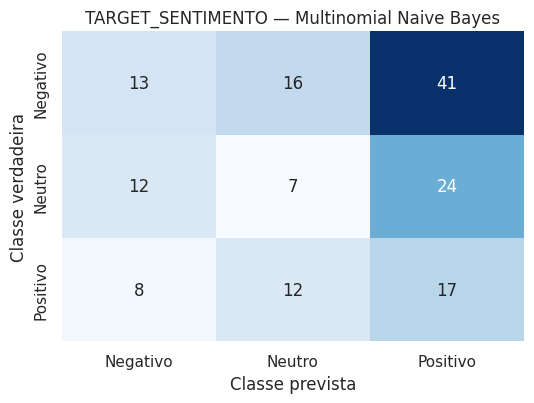


Baseline — sempre prevê 'Negativo'
              precision    recall  f1-score   support

    Negativo       0.47      1.00      0.64        70
      Neutro       0.00      0.00      0.00        43
    Positivo       0.00      0.00      0.00        37

    accuracy                           0.47       150
   macro avg       0.16      0.33      0.21       150
weighted avg       0.22      0.47      0.30       150



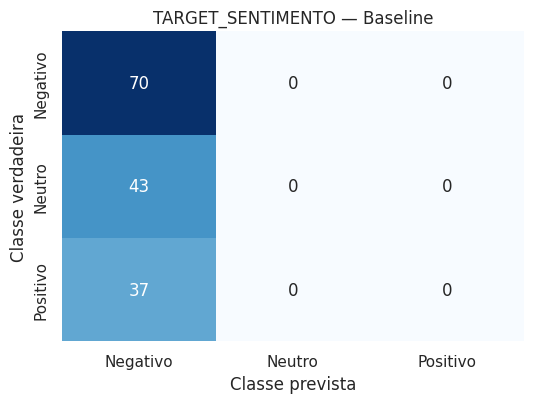

,Alvo,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_classe_1,Recall_classe_1,F1_classe_1,Precision_weighted,Recall_weighted,F1_weighted
0,TARGET_RISCO,Regressão Logística,0.453,0.438,0.433,0.431,0.598,0.500,0.544,0.487,0.453,0.465
1,TARGET_RISCO,Multinomial Naive Bayes,0.453,0.438,0.433,0.431,0.598,0.500,0.544,0.487,0.453,0.465
2,TARGET_RISCO,Baseline — classe majoritária,0.653,0.327,0.500,0.395,0.653,1.000,0.790,0.427,0.653,0.516
3,TARGET_OPORTUNIDADE,Regressão Logística,0.533,0.537,0.540,0.527,0.403,0.564,0.470,0.573,0.533,0.542
4,TARGET_OPORTUNIDADE,Multinomial Naive Bayes,0.533,0.537,0.540,0.527,0.403,0.564,0.470,0.573,0.533,0.542
5,TARGET_OPORTUNIDADE,Baseline — classe majoritária,0.633,0.317,0.500,0.388,0.000,0.000,0.000,0.401,0.633,0.491
6,TARGET_SENTIMENTO,Regressão Logística,0.247,0.267,0.269,0.239,nan,nan,nan,0.292,0.247,0.240
7,TARGET_SENTIMENTO,Multinomial Naive Bayes,0.247,0.267,0.269,0.239,nan,nan,nan,0.292,0.247,0.240
8,TARGET_SENTIMENTO,Baseline — classe majoritária,0.467,0.156,0.333,0.212,nan,nan,nan,0.218,0.467,0.297


,Alvo,Métrica_prioritária,Modelo_recomendado,Score_modelo,Score_baseline,Supera_baseline
0,TARGET_RISCO,Recall_classe_1,Regressão Logística,0.500,1.000,False
1,TARGET_OPORTUNIDADE,F1_classe_1,Regressão Logística,0.470,0.000,True
2,TARGET_SENTIMENTO,F1_macro,Regressão Logística,0.239,0.212,True


In [26]:
# 5. Treinamento, comparação, matrizes de confusão e seleção do modelo

prioridades = {
    'TARGET_RISCO': 'Recall_classe_1',
    'TARGET_OPORTUNIDADE': 'F1_classe_1',
    'TARGET_SENTIMENTO': 'F1_macro',
}


def classes_em_ordem(y):
    if y.dtype == 'object':
        ordem_sentimento = ['Negativo', 'Neutro', 'Positivo']
        presentes = [classe for classe in ordem_sentimento if classe in set(y.unique())]
        if presentes:
            return presentes
    return sorted(pd.unique(y).tolist())


def pesos_balanceados(y):
    frequencias = y.value_counts()
    n_classes = len(frequencias)
    return y.map(lambda classe: len(y) / (n_classes * frequencias[classe])).astype(float).to_numpy()


def construir_pipeline(nome_modelo):
    if nome_modelo == 'Regressão Logística':
        classificador = LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=42,
        )
    elif nome_modelo == 'Multinomial Naive Bayes':
        classificador = MultinomialNB()
    else:
        raise ValueError(f'Modelo desconhecido: {nome_modelo}')

    return Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True,
        )),
        ('clf', classificador),
    ])


def ajustar_pipeline(nome_modelo, textos, y):
    pipeline = construir_pipeline(nome_modelo)
    if nome_modelo == 'Multinomial Naive Bayes':
        pipeline.fit(textos, y, clf__sample_weight=pesos_balanceados(y))
    else:
        pipeline.fit(textos, y)
    return pipeline


def extrair_metricas(y_verdadeiro, y_predito, classes):
    relatorio = classification_report(
        y_verdadeiro,
        y_predito,
        labels=classes,
        output_dict=True,
        zero_division=0,
    )
    metricas = {
        'Accuracy': accuracy_score(y_verdadeiro, y_predito),
        'Precision_macro': relatorio['macro avg']['precision'],
        'Recall_macro': relatorio['macro avg']['recall'],
        'F1_macro': relatorio['macro avg']['f1-score'],
        'Precision_weighted': relatorio['weighted avg']['precision'],
        'Recall_weighted': relatorio['weighted avg']['recall'],
        'F1_weighted': relatorio['weighted avg']['f1-score'],
    }
    if set(classes) == {0, 1}:
        classe = relatorio.get('1', {'precision': 0, 'recall': 0, 'f1-score': 0})
        metricas.update({
            'Precision_classe_1': classe['precision'],
            'Recall_classe_1': classe['recall'],
            'F1_classe_1': classe['f1-score'],
        })
    else:
        metricas.update({
            'Precision_classe_1': np.nan,
            'Recall_classe_1': np.nan,
            'F1_classe_1': np.nan,
        })
    return metricas


def plotar_matriz(y_verdadeiro, y_predito, classes, titulo):
    matriz = confusion_matrix(y_verdadeiro, y_predito, labels=classes)
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    sns.heatmap(
        matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=classes, yticklabels=classes, ax=ax,
    )
    ax.set_title(titulo)
    ax.set_xlabel('Classe prevista')
    ax.set_ylabel('Classe verdadeira')
    plt.tight_layout()
    plt.show()


modelos_avaliados = ['Regressão Logística', 'Multinomial Naive Bayes']
metricas_linhas = []
modelos_teste = {}
erros_modelos = {}
particoes = {}

for alvo in alvos:
    y = df_reuniao[alvo]
    classes = classes_em_ordem(y)
    indices = df_reuniao.index.to_numpy()
    idx_treino, idx_teste = train_test_split(
        indices,
        test_size=0.30,
        stratify=y,
        random_state=42,
    )
    particoes[alvo] = {'treino': idx_treino, 'teste': idx_teste}

    textos_treino = df_reuniao.loc[idx_treino, 'FALA_LIMPA']
    textos_teste = df_reuniao.loc[idx_teste, 'FALA_LIMPA']
    y_treino = df_reuniao.loc[idx_treino, alvo]
    y_teste = df_reuniao.loc[idx_teste, alvo]

    modelos_teste[alvo] = {}
    erros_modelos[alvo] = {}

    print(f'\n{"=" * 76}\nAlvo: {alvo}\n{"=" * 76}')
    print('Distribuição no treino:', y_treino.value_counts().to_dict())
    print('Distribuição no teste:', y_teste.value_counts().to_dict())

    for nome_modelo in modelos_avaliados:
        modelo = ajustar_pipeline(nome_modelo, textos_treino, y_treino)
        predicoes = modelo.predict(textos_teste)
        modelos_teste[alvo][nome_modelo] = modelo

        metricas = extrair_metricas(y_teste, predicoes, classes)
        metricas.update({'Alvo': alvo, 'Modelo': nome_modelo})
        metricas_linhas.append(metricas)

        tabela_erros = df_reuniao.loc[idx_teste, ['ID_MEETING', 'FALA_LIMPA', alvo]].copy()
        tabela_erros = tabela_erros.rename(columns={alvo: 'Classe_verdadeira'})
        tabela_erros['Classe_predita'] = predicoes
        tabela_erros['Acertou'] = tabela_erros['Classe_verdadeira'] == tabela_erros['Classe_predita']
        erros_modelos[alvo][nome_modelo] = tabela_erros

        print(f'\n{nome_modelo}')
        print(classification_report(y_teste, predicoes, labels=classes, zero_division=0))
        plotar_matriz(y_teste, predicoes, classes, f'{alvo} — {nome_modelo}')

    classe_majoritaria = y_treino.mode().iloc[0]
    predicao_baseline = np.repeat(classe_majoritaria, len(y_teste))
    metricas_baseline = extrair_metricas(y_teste, predicao_baseline, classes)
    metricas_baseline.update({'Alvo': alvo, 'Modelo': 'Baseline — classe majoritária'})
    metricas_linhas.append(metricas_baseline)

    print(f'\nBaseline — sempre prevê {classe_majoritaria!r}')
    print(classification_report(y_teste, predicao_baseline, labels=classes, zero_division=0))
    plotar_matriz(y_teste, predicao_baseline, classes, f'{alvo} — Baseline')


df_metricas = pd.DataFrame(metricas_linhas)
colunas_ordem = [
    'Alvo', 'Modelo', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro',
    'Precision_classe_1', 'Recall_classe_1', 'F1_classe_1',
    'Precision_weighted', 'Recall_weighted', 'F1_weighted',
]
df_metricas = df_metricas[[coluna for coluna in colunas_ordem if coluna in df_metricas.columns]]
display(df_metricas.style.format({coluna: '{:.3f}' for coluna in df_metricas.columns if coluna not in {'Alvo', 'Modelo'}}))

# Escolha dos modelos apenas entre os algoritmos supervisionados, nunca pelo baseline.
recomendacoes = []
for alvo in alvos:
    metrica_prioritaria = prioridades[alvo]
    candidatos = df_metricas[(df_metricas['Alvo'] == alvo) & (df_metricas['Modelo'].isin(modelos_avaliados))].copy()
    melhor = candidatos.sort_values(metrica_prioritaria, ascending=False).iloc[0]
    baseline = df_metricas[(df_metricas['Alvo'] == alvo) & (df_metricas['Modelo'].str.startswith('Baseline'))].iloc[0]
    recomendacoes.append({
        'Alvo': alvo,
        'Métrica_prioritária': metrica_prioritaria,
        'Modelo_recomendado': melhor['Modelo'],
        'Score_modelo': melhor[metrica_prioritaria],
        'Score_baseline': baseline[metrica_prioritaria],
        'Supera_baseline': bool(melhor[metrica_prioritaria] > baseline[metrica_prioritaria]),
    })

df_recomendacoes = pd.DataFrame(recomendacoes)
display(df_recomendacoes.style.format({'Score_modelo': '{:.3f}', 'Score_baseline': '{:.3f}'}))

## 5. Análise dos erros

A análise de erros transforma as métricas em implicações operacionais. Para churn, observamos principalmente falsos negativos — reuniões realmente classificadas como risco que o modelo marcou como seguras. Para oportunidade comercial, examinamos falsos negativos e falsos positivos da classe 1. Para sentimento, observamos quais pares de classes são mais confundidos pela matriz de confusão.

A interpretação deve ser feita sobre exemplos do conjunto de teste, sem utilizar esses exemplos para reajustar o modelo. Se muitos erros forem semanticamente ambíguos, a próxima etapa recomendada é ampliar a amostra e criar rótulos humanos mais específicos.

In [27]:
# 6. Exemplos de erros dos modelos recomendados
for recomendacao in recomendacoes:
    alvo = recomendacao['Alvo']
    nome_modelo = recomendacao['Modelo_recomendado']
    tabela_erros = erros_modelos[alvo][nome_modelo]
    incorretos = tabela_erros[~tabela_erros['Acertou']].copy()

    print(f'\nAlvo: {alvo} | Modelo: {nome_modelo} | Erros: {len(incorretos)}')
    if incorretos.empty:
        print('Nenhum erro no conjunto de teste.')
        continue

    if alvo == 'TARGET_RISCO':
        incorretos['Tipo_erro'] = np.where(
            (incorretos['Classe_verdadeira'] == 1) & (incorretos['Classe_predita'] == 0),
            'Falso negativo — risco não detectado',
            'Falso positivo — alerta sem risco',
        )
    elif alvo == 'TARGET_OPORTUNIDADE':
        incorretos['Tipo_erro'] = np.where(
            (incorretos['Classe_verdadeira'] == 1) & (incorretos['Classe_predita'] == 0),
            'Falso negativo — oportunidade perdida',
            'Falso positivo — encaminhamento indevido',
        )
    else:
        incorretos['Tipo_erro'] = (
            incorretos['Classe_verdadeira'].astype(str) + ' previsto como ' +
            incorretos['Classe_predita'].astype(str)
        )

    colunas_exibicao = ['ID_MEETING', 'Classe_verdadeira', 'Classe_predita', 'Tipo_erro', 'FALA_LIMPA']
    display(incorretos[colunas_exibicao].head(10))


Alvo: TARGET_RISCO | Modelo: Regressão Logística | Erros: 82


,ID_MEETING,Classe_verdadeira,Classe_predita,Tipo_erro,FALA_LIMPA
214,1000214,1,0,Falso negativo — risco não detectado,querem fazer teste queria preciso conversar só...
228,1000228,1,0,Falso negativo — risco não detectado,querem fazer teste queria preciso conversar só...
462,1000462,1,0,Falso negativo — risco não detectado,querem fazer teste queria preciso conversar só...
84,1000084,0,1,Falso positivo — alerta sem risco,boa tarde obrigado vir boa tarde gente querend...
393,1000393,1,0,Falso negativo — risco não detectado,solução conecta todas lojas plataforma funcion...
410,1000410,1,0,Falso negativo — risco não detectado,querem fazer teste queria preciso conversar só...
5,1000005,0,1,Falso positivo — alerta sem risco,preço trabalhamos pacotes customizados uns 15 ...
144,1000144,1,0,Falso negativo — risco não detectado,querem fazer teste queria preciso conversar só...
151,1000151,0,1,Falso positivo — alerta sem risco,preço trabalhamos pacotes customizados uns 15 ...
373,1000373,0,1,Falso positivo — alerta sem risco,preço trabalhamos pacotes customizados uns 15 ...



Alvo: TARGET_OPORTUNIDADE | Modelo: Regressão Logística | Erros: 70


,ID_MEETING,Classe_verdadeira,Classe_predita,Tipo_erro,FALA_LIMPA
273,1000273,1,0,Falso negativo — oportunidade perdida,boa tarde obrigado vir boa tarde gente querend...
372,1000372,0,1,Falso positivo — encaminhamento indevido,preço trabalhamos pacotes customizados uns 15 ...
138,1000138,0,1,Falso positivo — encaminhamento indevido,preço trabalhamos pacotes customizados uns 15 ...
348,1000348,0,1,Falso positivo — encaminhamento indevido,preço trabalhamos pacotes customizados uns 15 ...
346,1000346,0,1,Falso positivo — encaminhamento indevido,preço trabalhamos pacotes customizados uns 15 ...
436,1000436,1,0,Falso negativo — oportunidade perdida,solução conecta todas lojas plataforma funcion...
496,1000496,0,1,Falso positivo — encaminhamento indevido,querem fazer teste queria preciso conversar só...
80,1000080,0,1,Falso positivo — encaminhamento indevido,preço trabalhamos pacotes customizados uns 15 ...
362,1000362,1,0,Falso negativo — oportunidade perdida,solução conecta todas lojas plataforma funcion...
98,1000098,1,0,Falso negativo — oportunidade perdida,boa tarde obrigado vir boa tarde gente querend...



Alvo: TARGET_SENTIMENTO | Modelo: Regressão Logística | Erros: 113


,ID_MEETING,Classe_verdadeira,Classe_predita,Tipo_erro,FALA_LIMPA
156,1000156,Negativo,Positivo,Negativo previsto como Positivo,solução conecta todas lojas plataforma funcion...
438,1000438,Positivo,Neutro,Positivo previsto como Neutro,boa tarde obrigado vir boa tarde gente querend...
103,1000103,Negativo,Neutro,Negativo previsto como Neutro,boa tarde obrigado vir boa tarde gente querend...
73,1000073,Neutro,Positivo,Neutro previsto como Positivo,solução conecta todas lojas plataforma funcion...
194,1000194,Negativo,Positivo,Negativo previsto como Positivo,preço trabalhamos pacotes customizados uns 15 ...
313,1000313,Negativo,Positivo,Negativo previsto como Positivo,preço trabalhamos pacotes customizados uns 15 ...
373,1000373,Neutro,Positivo,Neutro previsto como Positivo,preço trabalhamos pacotes customizados uns 15 ...
274,1000274,Negativo,Positivo,Negativo previsto como Positivo,preço trabalhamos pacotes customizados uns 15 ...
106,1000106,Positivo,Negativo,Positivo previsto como Negativo,querem fazer teste queria preciso conversar só...
493,1000493,Negativo,Positivo,Negativo previsto como Positivo,solução conecta todas lojas plataforma funcion...


## 6. Aplicação na base real: produtos, risco, oportunidade e sentimento

A base JSON não possui os rótulos necessários para calcular acurácia, precisão, recall ou F1. Portanto, as previsões abaixo são **inferências de triagem** produzidas pelos modelos treinados no CSV, e não uma validação externa.

Além das três previsões supervisionadas, a etapa identifica menções diretas a produtos TOTVS por expressões regulares. Essa extração é auditável e permite revisar os trechos localizados, mas pode gerar falsos positivos ou deixar passar sinônimos; por isso, os resultados devem ser revisados antes de uma ação comercial.

In [28]:
# 7. Inferência na base JSON e extração de produtos TOTVS

PADROES_PRODUTOS = {
    'RM': r'\brm\b',
    'Fluig': r'\bfluig\b',
    'Protheus': r'\bprotheus\b',
    'Datasul': r'\bdatasul\b',
    'TOTVS': r'\btotvs\b',
}

def produtos_mencionados(texto):
    texto = '' if pd.isna(texto) else str(texto)
    return [
        produto for produto, padrao in PADROES_PRODUTOS.items()
        if re.search(padrao, texto, flags=re.IGNORECASE)
    ]


df_json_trechos = segmentar_transcricoes(
    df_json,
    coluna_texto='ANON_TRANSCRICAO',
    coluna_id='ID_MEETING',
)
if df_json_trechos.empty:
    raise ValueError('Nenhuma fala válida foi encontrada no JSON.')

df_json_trechos['FALA_LIMPA'] = df_json_trechos['FALA_BRUTA'].apply(limpar_texto)

df_json_reuniao = (
    df_json_trechos.groupby('ID_MEETING', as_index=False)
    .agg({
        'FALA_BRUTA': ' '.join,
        'FALA_LIMPA': ' '.join,
    })
)
df_json_reuniao['PRODUTOS_DETECTADOS'] = df_json_reuniao['FALA_BRUTA'].apply(produtos_mencionados)

# Re-treino dos melhores algoritmos com todas as reuniões rotuladas antes da inferência.
modelos_producao = {}
for recomendacao in recomendacoes:
    alvo = recomendacao['Alvo']
    nome_modelo = recomendacao['Modelo_recomendado']
    modelos_producao[alvo] = ajustar_pipeline(
        nome_modelo,
        df_reuniao['FALA_LIMPA'],
        df_reuniao[alvo],
    )
    coluna_predicao = {
        'TARGET_RISCO': 'PRED_RISCO',
        'TARGET_OPORTUNIDADE': 'PRED_OPORTUNIDADE',
        'TARGET_SENTIMENTO': 'PRED_SENTIMENTO',
    }[alvo]
    df_json_reuniao[coluna_predicao] = modelos_producao[alvo].predict(df_json_reuniao['FALA_LIMPA'])

# Resumo de produtos mencionados.
produtos_explodidos = df_json_reuniao[['ID_MEETING', 'PRODUTOS_DETECTADOS']].explode('PRODUTOS_DETECTADOS')
resumo_produtos = (
    produtos_explodidos.dropna(subset=['PRODUTOS_DETECTADOS'])
    .groupby('PRODUTOS_DETECTADOS')
    .size()
    .sort_values(ascending=False)
    .rename('Reuniões_com_menção')
    .reset_index()
)

print(f'JSON segmentado em {df_json_trechos.shape[0]} falas e {df_json_reuniao.shape[0]} reuniões.')
print('Distribuição das previsões supervisionadas:')
for coluna in ['PRED_RISCO', 'PRED_OPORTUNIDADE', 'PRED_SENTIMENTO']:
    print(f'\n{coluna}')
    display(df_json_reuniao[coluna].value_counts(dropna=False).rename_axis('Classe').reset_index(name='Quantidade'))

print('Resumo de menções a produtos:')
display(resumo_produtos)

print('Amostra para auditoria humana:')
colunas_auditoria = [
    'ID_MEETING', 'PRED_RISCO', 'PRED_OPORTUNIDADE',
    'PRED_SENTIMENTO', 'PRODUTOS_DETECTADOS', 'FALA_BRUTA',
]
display(df_json_reuniao[colunas_auditoria].head(20))

# Arquivo de saída para posterior revisão pela equipe.
ARQUIVO_SAIDA_JSON = Path.cwd() / 'predicoes_json_reunioes.csv'
df_json_reuniao.to_csv(ARQUIVO_SAIDA_JSON, index=False, encoding='utf-8-sig')
print(f'Resultado salvo em: {ARQUIVO_SAIDA_JSON}')

JSON segmentado em 338710 falas e 1126 reuniões.
Distribuição das previsões supervisionadas:

PRED_RISCO


,Classe,Quantidade
0,1,1080
1,0,46



PRED_OPORTUNIDADE


,Classe,Quantidade
0,1,1105
1,0,21



PRED_SENTIMENTO


...

Resumo de menções a produtos:


,PRODUTOS_DETECTADOS,Reuniões_com_menção
0,RM,288
1,Fluig,167
2,Datasul,9
3,TOTVS,2
4,Protheus,1


Amostra para auditoria humana:


,ID_MEETING,PRED_RISCO,PRED_OPORTUNIDADE,PRED_SENTIMENTO,PRODUTOS_DETECTADOS,FALA_BRUTA
0,687645,1,1,Neutro,[RM],"Olá [PESSOA]. Olá [PESSOA], tudo bem? Bom dia...."
1,687654,1,1,Neutro,[RM],[LOCAL]. Com o cliente que tá tudo certo. [LOC...
2,691110,1,1,Neutro,[],"[EMPRESA], [PESSOA]. [EMPRESA], boa tarde. Boa..."
3,699839,1,1,Neutro,[],"É uma mescla, né? Já já a gente vai ter robô t..."
4,702831,1,1,Neutro,[RM],[PESSOA]. Fala meu querido tudo bem. Tudo ótim...
5,702921,1,1,Neutro,[RM],"[PESSOA], boa tarde, tudo bem? [PESSOA], eu tô..."
6,702922,1,1,Neutro,"[RM, Fluig]","Eu entendo que, nesse momento, é importante ir..."
7,702925,1,1,Neutro,[RM],"Boa tarde, pessoal. Boa tarde. Olá, boa tarde...."
8,703825,1,1,Neutro,[],[LOCUTOR 1]: é que é? Consegue um tempinho pra...
9,704620,0,1,Neutro,[],"[EMPRESA]. [EMPRESA], [PESSOA], tudo bem? Tudo..."


Resultado salvo em: /content/predicoes_json_reunioes.csv


## 7. Conclusões e implicações para o negócio

A avaliação deve ser concluída a partir das tabelas e matrizes geradas na execução atual, e não de números copiados de uma execução anterior. O modelo recomendado para cada alvo é selecionado pela métrica prioritária e comparado ao baseline de classe majoritária.

Para **risco de churn**, a decisão operacional deve priorizar a redução de falsos negativos da classe 1. Um alerta falso pode consumir tempo da equipe de relacionamento, mas um risco não detectado pode representar uma oportunidade perdida de retenção. Para **oportunidade comercial**, o F1-score da classe 1 é um compromisso entre cobertura e qualidade dos encaminhamentos para Vendas. Para **sentimento**, o F1 macro é preferível à acurácia quando as classes Negativo, Neutro e Positivo não estão equilibradas.

A etapa de produtos amplia o uso do pipeline: menções a Protheus, RM, Fluig, Datasul e TOTVS podem apoiar segmentação de contas, identificação de oportunidades de cross-sell e priorização de auditorias. Entretanto, uma menção não comprova intenção de compra, insatisfação ou necessidade de expansão.

### Limitações que precisam constar na entrega

A variável de churn é um proxy de NPS, não uma confirmação de cancelamento. A variável de oportunidade é um proxy de área/recurso, não uma anotação textual humana. O sentimento é derivado do NPS e pode não coincidir com a emoção expressa em cada fala. A base disponível é pequena e parcialmente simulada, a avaliação usa uma divisão treino/teste única e a inferência no JSON não tem gabarito para validação. Por esses motivos, os resultados devem ser apresentados como um experimento supervisionado e uma prova de conceito, não como um modelo pronto para decisão automática.

### Checklist de atendimento à rubrica

| Critério da avaliação | Onde é atendido |
|---|---|
| Preparação da variável-alvo e definição do problema | Seções 1 e 2, com as três definições e suas limitações. |
| Análise das classes e eventual balanceamento | Seção 3, tabela/gráfico de distribuição e pesos no treinamento. |
| Construção dos modelos de classificação | Seção 4 e célula de treinamento com Regressão Logística e Multinomial Naive Bayes. |
| Avaliação e comparação dos modelos | Accuracy, precisão, recall, F1, baseline e matrizes de confusão. |
| Análise dos erros | Seção 5, com exemplos do conjunto de teste e tipos de erro. |
| Conclusões e implicações para o negócio | Seção 7, com métricas prioritárias, produtos e limitações. |

> O critério de sucesso não é apenas obter a maior acurácia. É demonstrar que a métrica escolhida corresponde ao custo de negócio, que o modelo supera uma referência simples e que seus erros são conhecidos.

## Referências metodológicas

As decisões de implementação utilizam as interfaces oficiais do scikit-learn para pipelines, vetorização TF-IDF e avaliação de classificadores.

[1]: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html "scikit-learn — Pipeline"  
[2]: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html "scikit-learn — TfidfVectorizer"  
[3]: https://scikit-learn.org/stable/modules/model_evaluation.html "scikit-learn — Model evaluation: quantifying the quality of predictions"